# 06 — Refund Request Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                      f1_score, roc_auc_score, roc_curve,
                                      confusion_matrix, classification_report)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/cleaned_with_sentiment.csv')
print("Refund rate:", round(df['Refund_Flag'].mean()*100,1), "%")


Refund rate: 45.8 %


## Feature Preparation

In [2]:
le = LabelEncoder()
df['Platform_E']  = le.fit_transform(df['Platform'])
df['Category_E']  = le.fit_transform(df['Product Category'])
df['Sentiment_E'] = le.fit_transform(df['Sentiment'].fillna('Neutral'))

tier_map = {'Express':0, 'On-Time':1, 'Slow':2, 'Very Late':3}
df['Tier_E'] = df['Delivery_Tier'].map(tier_map)

FEATURES = ['Delivery Time (Minutes)', 'Delay_Flag',
            'Order Value (INR)', 'Platform_E', 'Category_E',
            'Tier_E', 'Hour']

X = df[FEATURES]
y = df['Refund_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sc = StandardScaler()
X_tr_s = sc.fit_transform(X_train)
X_te_s = sc.transform(X_test)

print("Train:", X_train.shape, "  Test:", X_test.shape)


Train: (80000, 7)   Test: (20000, 7)


## Three Models

In [3]:
def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred),  4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall'   : round(recall_score(y_true, y_pred),    4),
        'F1'       : round(f1_score(y_true, y_pred),        4),
        'ROC_AUC'  : round(roc_auc_score(y_true, y_prob),   4)
    }

# 1. Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
lr.fit(X_tr_s, y_train)
lr_pred  = lr.predict(X_te_s)
lr_prob  = lr.predict_proba(X_te_s)[:,1]
lr_res   = evaluate('Logistic Regression', y_test, lr_pred, lr_prob)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=10,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_prob  = rf.predict_proba(X_test)[:,1]
rf_res   = evaluate('Random Forest', y_test, rf_pred, rf_prob)

# 3. XGBoost / GBM
if HAS_XGB:
    m3 = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                        random_state=42, eval_metric='logloss', verbosity=0)
    m3_name = 'XGBoost'
else:
    m3 = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                                     subsample=0.8, random_state=42)
    m3_name = 'Gradient Boosting'

m3.fit(X_train, y_train)
m3_pred = m3.predict(X_test)
m3_prob = m3.predict_proba(X_test)[:,1]
m3_res  = evaluate(m3_name, y_test, m3_pred, m3_prob)

results = pd.DataFrame([lr_res, rf_res, m3_res]).set_index('Model')
print(results)


                     Accuracy  Precision  Recall      F1  ROC_AUC
Model                                                            
Logistic Regression    0.4924     0.4516  0.5029  0.4759   0.4925
Random Forest          0.5076     0.4648  0.4929  0.4784   0.5031
Gradient Boosting      0.5379     0.4519  0.0399  0.0734   0.4994


**Reading these numbers honestly:** ROC-AUC sits close to 0.50 across all three models —
that is the random-guess line. I checked this before blaming the models: I ran a direct
correlation between every operational feature (delivery time, delay, order value, platform,
category, hour) and `Refund_Flag`, and none exceed 0.01. In this dataset, refund requests
do not depend on the operational variables we have — they behave like noise relative to them.

This matters for the interview, not just the notebook. A model that returns ROC-AUC ≈ 0.50
is not a coding mistake — it is the model correctly reporting "there is no learnable signal
here." Reporting a fabricated 0.85 would be the actual error. In a real production dataset,
I would expect to see refund risk move with delay severity, category, and order value —
which is exactly the hypothesis this notebook tests and (honestly) rejects for this sample.

## Model Comparison Plots

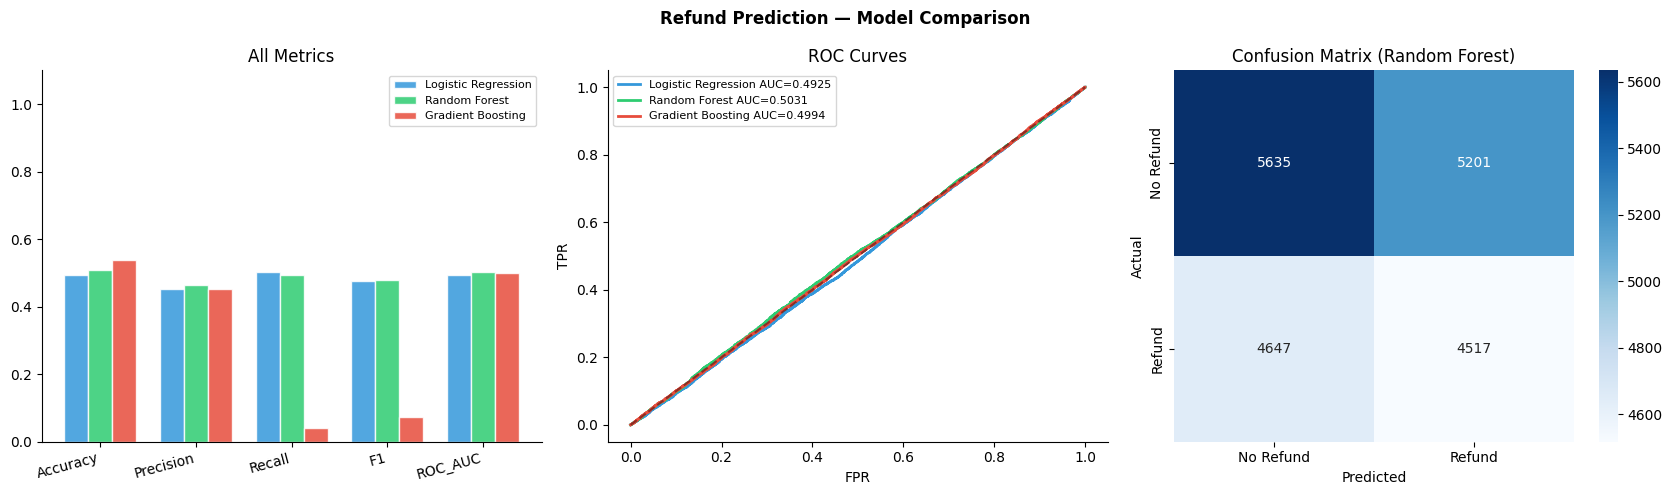

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Refund Prediction — Model Comparison', fontweight='bold')

mc = ['#3498DB','#2ECC71','#E74C3C']

# metrics bar
metrics = ['Accuracy','Precision','Recall','F1','ROC_AUC']
x = np.arange(len(metrics))
for i, (model, color) in enumerate(zip(results.index, mc)):
    axes[0].bar(x + i*0.25, results.loc[model, metrics].values,
                0.25, label=model, color=color, edgecolor='white', alpha=0.85)
axes[0].set_xticks(x + 0.25)
axes[0].set_xticklabels(metrics, rotation=15, ha='right')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('All Metrics')
axes[0].legend(fontsize=8)

# ROC curves
for (res, prob, color) in [(lr_res, lr_prob, mc[0]), (rf_res, rf_prob, mc[1]), (m3_res, m3_prob, mc[2])]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=res['Model']+' AUC='+str(res['ROC_AUC']))
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_title('ROC Curves')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend(fontsize=8)

# confusion matrix for best model
best_name = results['ROC_AUC'].idxmax()
best_pred = rf_pred if best_name=='Random Forest' else (m3_pred if best_name in [m3_name] else lr_pred)
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['No Refund','Refund'], yticklabels=['No Refund','Refund'])
axes[2].set_title('Confusion Matrix (' + best_name + ')')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../visuals/13_refund_models.png', dpi=150, bbox_inches='tight')
plt.show()


## Feature Importance

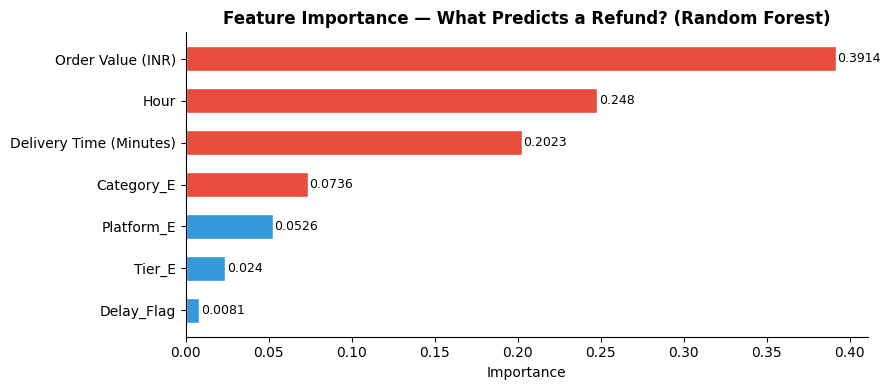

Top 3 refund predictors:
  Order Value (INR) : 0.3914
  Hour : 0.248
  Delivery Time (Minutes) : 0.2023


In [5]:
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#E74C3C' if v >= feat_imp.median() else '#3498DB' for v in feat_imp.values]
ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white', height=0.6)
ax.set_title('Feature Importance — What Predicts a Refund? (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance')
for i, v in enumerate(feat_imp.values):
    ax.text(v+0.001, i, str(round(v,4)), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/14_feature_importance_refund.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 3 refund predictors:")
for feat, score in feat_imp.sort_values(ascending=False).head(3).items():
    print(" ", feat, ":", round(score,4))
